In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Number of records
n = 1500

# Generate logistics features
distance = np.random.randint(20, 1001, n)

weight = np.round(
    np.random.uniform(0.5, 30, n),
    2
)

items = np.random.randint(1, 11, n)

shipping_cost = np.round(
    150 + distance * 1.2 + weight * 15 + np.random.normal(0, 50, n),
    2
)

processing_hours = np.round(
    np.random.uniform(2, 24, n),
    2
)

traffic_level = np.random.choice(
    ["Low", "Medium", "High"],
    n,
    p=[0.35, 0.40, 0.25]
)

# Convert traffic into numerical effect
traffic_effect = np.select(
    [
        traffic_level == "Low",
        traffic_level == "Medium",
        traffic_level == "High"
    ],
    [0.2, 0.8, 1.5]
)

# Create target variable: Delivery Days
delivery_days = np.round(
    1.2
    + (distance / 250)
    + (weight / 25)
    + (items * 0.08)
    + (processing_hours / 24)
    + traffic_effect
    + np.random.normal(0, 0.3, n),
    2
)

# Create DataFrame
logistics_df = pd.DataFrame({
    "Distance_km": distance,
    "Weight_kg": weight,
    "Number_of_Items": items,
    "Shipping_Cost": shipping_cost,
    "Processing_Hours": processing_hours,
    "Traffic_Level": traffic_level,
    "Delivery_Days": delivery_days
})

print("Dataset created successfully!")
print("Dataset Shape:", logistics_df.shape)

display(logistics_df.head())

Dataset created successfully!
Dataset Shape: (1500, 7)


,Distance_km,Weight_kg,Number_of_Items,Shipping_Cost,Processing_Hours,Traffic_Level,Delivery_Days
0,412,15.14,5,864.97,13.68,High,5.74
1,886,11.73,10,1417.44,7.62,Low,6.59
2,783,5.31,8,1172.86,16.86,Medium,7.13
3,864,23.69,5,1488.88,13.94,High,7.83
4,226,22.17,9,745.46,7.13,Medium,4.82


In [4]:
# Basic dataset information

print("Dataset Shape:", logistics_df.shape)

print("\nColumn Names:")
print(logistics_df.columns.tolist())

print("\nData Types:")
print(logistics_df.dtypes)

print("\nMissing Values:")
print(logistics_df.isnull().sum())

print("\nDuplicate Rows:", logistics_df.duplicated().sum())

Dataset Shape: (1500, 7)

Column Names:
['Distance_km', 'Weight_kg', 'Number_of_Items', 'Shipping_Cost', 'Processing_Hours', 'Traffic_Level', 'Delivery_Days']

Data Types:
Distance_km           int32
Weight_kg           float64
Number_of_Items       int32
Shipping_Cost       float64
Processing_Hours    float64
Traffic_Level           str
Delivery_Days       float64
dtype: object

Missing Values:
Distance_km         0
Weight_kg           0
Number_of_Items     0
Shipping_Cost       0
Processing_Hours    0
Traffic_Level       0
Delivery_Days       0
dtype: int64

Duplicate Rows: 0


In [5]:
# Statistical summary

display(logistics_df.describe())

,Distance_km,Weight_kg,Number_of_Items,Shipping_Cost,Processing_Hours,Delivery_Days
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,517.790000,14.937400,5.530000,994.364833,13.092733,5.616127
std,278.817616,8.446207,2.887674,367.395555,6.389452,1.389908
min,20.000000,0.500000,1.000000,189.990000,2.030000,1.830000
25%,282.750000,7.597500,3.000000,689.555000,7.747500,4.597500
50%,527.500000,14.880000,6.000000,1007.110000,13.155000,5.635000
75%,753.000000,22.065000,8.000000,1293.057500,18.700000,6.640000
max,1000.000000,29.990000,10.000000,1839.400000,23.990000,9.210000


In [6]:
# Convert Traffic Level into numerical values

logistics_df["Traffic_Level"] = logistics_df["Traffic_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

print("Traffic Level encoded successfully!")

display(logistics_df.head())

Traffic Level encoded successfully!


,Distance_km,Weight_kg,Number_of_Items,Shipping_Cost,Processing_Hours,Traffic_Level,Delivery_Days
0,412,15.14,5,864.97,13.68,2,5.74
1,886,11.73,10,1417.44,7.62,0,6.59
2,783,5.31,8,1172.86,16.86,1,7.13
3,864,23.69,5,1488.88,13.94,2,7.83
4,226,22.17,9,745.46,7.13,1,4.82


In [7]:
print(logistics_df["Traffic_Level"].value_counts())

Traffic_Level
1    620
0    513
2    367
Name: count, dtype: int64


In [8]:
logistics_df.to_csv(
    "logistics_simulated_dataset.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [9]:
# Define features and target

X = logistics_df.drop("Delivery_Days", axis=1)
y = logistics_df["Delivery_Days"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Features (X):
['Distance_km', 'Weight_kg', 'Number_of_Items', 'Shipping_Cost', 'Processing_Hours', 'Traffic_Level']

Target (y):
Delivery_Days

X Shape: (1500, 6)
y Shape: (1500,)


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1200, 6)
Testing data: (300, 6)


In [15]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [16]:
# Make predictions on test data

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted Values:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Actual Values:
[4.19 8.28 7.79 5.41 8.63 6.05 4.19 6.34 4.01 4.99]

First 10 Predicted Values:
[4.91924519 7.72130266 7.7216174  5.6370248  8.20120815 5.40784862
 4.17489384 6.27872647 4.10369627 5.19247641]


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

Linear Regression Performance
--------------------------------
MAE : 0.25
RMSE: 0.308
R² Score: 0.951


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("\nFirst 10 Predictions:")
print(rf_pred[:10])

Random Forest predictions generated successfully!

First 10 Predictions:
[5.1228 7.6617 7.2044 5.861  8.4114 5.6222 3.7728 6.0805 3.7277 5.1998]


In [20]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R² Score:", round(rf_r2, 3))

Random Forest Performance
-------------------------
MAE : 0.309
RMSE: 0.379
R² Score: 0.926


In [21]:
# Compare both models

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R2 Score": [
        r2,
        rf_r2
    ]
})

display(comparison.round(3))


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.250,0.308,0.951
1,Random Forest,0.309,0.379,0.926


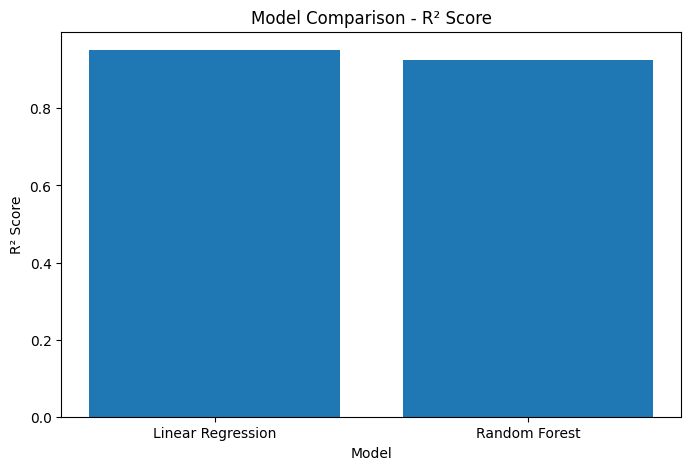

In [22]:
# Model performance comparison

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [23]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

print("Best Performing Model:", best_model)

Best Performing Model: Linear Regression


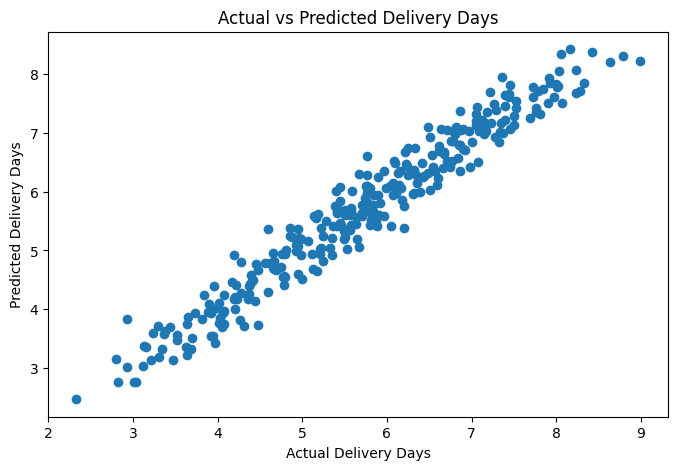

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title("Actual vs Predicted Delivery Days")

plt.show()

In [25]:
# Feature impact using Linear Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
5,Traffic_Level,0.652535
2,Number_of_Items,0.080702
1,Weight_kg,0.040248
4,Processing_Hours,0.038016
0,Distance_km,0.004045
3,Shipping_Cost,-0.000040


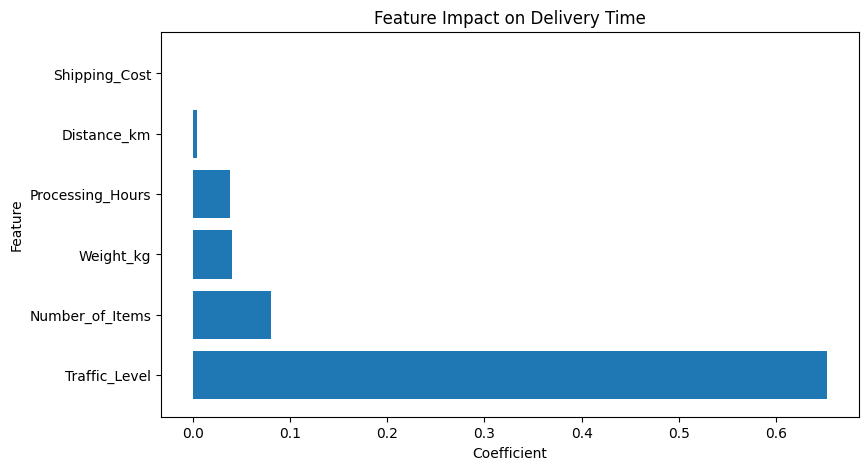

In [26]:
plt.figure(figsize=(9, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Impact on Delivery Time")

plt.show()

In [27]:
# Optimization scenario
# Reduce processing time for high-distance shipments

optimized_data = X_test.copy()

# Reduce processing hours by 20%
optimized_data["Processing_Hours"] = (
    optimized_data["Processing_Hours"] * 0.80
)

# Predict delivery time before optimization
before_optimization = linear_model.predict(X_test)

# Predict delivery time after optimization
after_optimization = linear_model.predict(optimized_data)

# Calculate average delivery time
avg_before = before_optimization.mean()
avg_after = after_optimization.mean()

print("Average Delivery Time Before Optimization:",
      round(avg_before, 2), "days")

print("Average Delivery Time After Optimization:",
      round(avg_after, 2), "days")

print("Estimated Improvement:",
      round(avg_before - avg_after, 2), "days")

Average Delivery Time Before Optimization: 5.7 days
Average Delivery Time After Optimization: 5.6 days
Estimated Improvement: 0.1 days


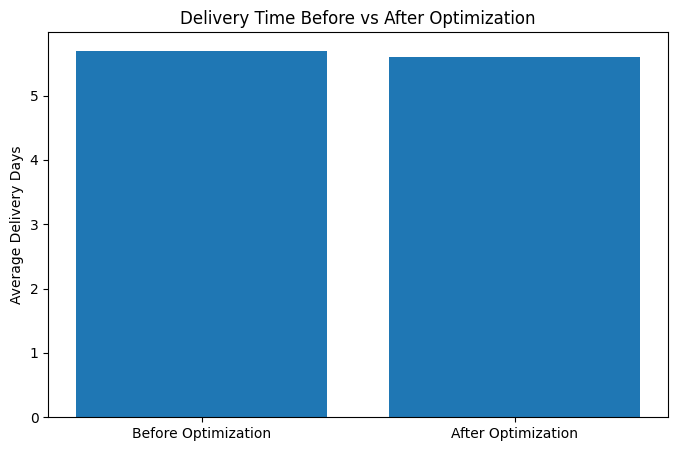

In [28]:
comparison_data = pd.DataFrame({
    "Scenario": [
        "Before Optimization",
        "After Optimization"
    ],
    "Average_Delivery_Days": [
        avg_before,
        avg_after
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_data["Scenario"],
    comparison_data["Average_Delivery_Days"]
)

plt.ylabel("Average Delivery Days")
plt.title("Delivery Time Before vs After Optimization")

plt.show()

In [29]:
# Correlation analysis

correlation = logistics_df.corr(numeric_only=True)

display(correlation.round(2))

,Distance_km,Weight_kg,Number_of_Items,Shipping_Cost,Processing_Hours,Traffic_Level,Delivery_Days
Distance_km,1.00,0.05,0.04,0.93,0.06,0.03,0.84
Weight_kg,0.05,1.00,-0.00,0.38,-0.00,-0.03,0.27
Number_of_Items,0.04,-0.00,1.00,0.04,0.02,0.02,0.21
Shipping_Cost,0.93,0.38,0.04,1.00,0.05,0.02,0.86
Processing_Hours,0.06,-0.00,0.02,0.05,1.00,0.07,0.25
Traffic_Level,0.03,-0.03,0.02,0.02,0.07,1.00,0.38
Delivery_Days,0.84,0.27,0.21,0.86,0.25,0.38,1.00


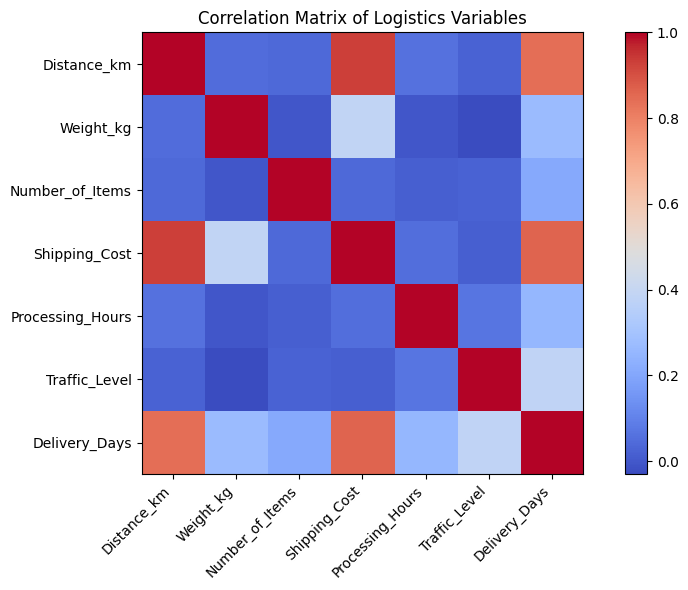

In [30]:
plt.figure(figsize=(9, 6))

plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Logistics Variables")

plt.tight_layout()
plt.show()

In [31]:
print("FINAL MODEL SUMMARY")
print("-------------------")
print("Best Model:", best_model)
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

FINAL MODEL SUMMARY
-------------------
Best Model: Linear Regression
MAE: 0.25
RMSE: 0.308
R² Score: 0.951


# Conclusion

This project developed a predictive model for estimating logistics delivery time using simulated logistics data.

The analysis considered factors such as distance, shipment weight, number of items, shipping cost, processing time, and traffic level. Linear Regression and Random Forest Regression models were trained and evaluated using MAE, RMSE, and R² Score.

Linear Regression achieved the better performance with an MAE of 0.250, RMSE of 0.308, and R² Score of 0.951. Therefore, Linear Regression was selected as the best-performing model for this simulated logistics problem.

The analysis also demonstrated how predictive modeling can support logistics decision-making. Reducing warehouse processing time was considered as an optimization scenario, where the trained model was used to estimate the potential reduction in delivery time.

Based on the analysis, logistics organizations can improve operational efficiency by reducing processing delays, optimizing resource allocation, managing long-distance shipments effectively, and considering traffic conditions during delivery planning.